## In this notebook the main objective is to asses mulitple model to find the best model in order to asses the stated problem. 

### The stated problem:

A dataset for a binary classification problem related to wildfires in California, the goal is to predict wheter a wildfire will occur `WildfireOccured` 1 or 0 based on the categorical and other various features

- Logistic Regression simpler model
- Random Forest a more complex model
- Finish with Gradient Boosting (XGM boosting / LightGBM) hyperparamter / cross-validation

In [119]:
#Import pandas, matplotlib.pyplot, and seaborn in the correct lines below
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import os
import time
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

##### In the previous step we included AcresBurn as one of the event features, but this is a post event so we need to drop it or else the model can easily predict if a wildfire will occur just by looking at the AcresBurned which is pretty much a strong binary indicator if a wildfire will occur or not.

In [6]:
from sklearn.model_selection import train_test_split

wildfire = pd.read_csv("..\\data\\wildfire_data_preprocessed.csv")

# Define feature matrix X and target vector y
X = wildfire.drop(columns=['WildfireOccurred', 'AcresBurned', 'Started', 'Date', 'Counties', 'ArchiveYear'])
y = wildfire['WildfireOccurred']

# Split the data into training and testing sets (70/30 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Display the shape of the resulting splits
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2004, 12)
X_test shape: (860, 12)
y_train shape: (2004,)
y_test shape: (860,)


In [7]:
wildfire.head()

,Latitude,Longitude,ArchiveYear,Started,AcresBurned,Counties,WildfireOccurred,Date,Temperature,Humidity,WindSpeed,Precipitation,Region_Northern California,Region_Southern California,Region_Western California,Season_Spring,Season_Summer,Season_Winter
0,40.785933,-121.017469,2013,2013-01-01 08:14:00+00:00,0,Lassen,0,1/1/2013,-3.46,1.41,-0.23,-0.22,1,0,0,0,0,1
1,33.469231,-115.114638,2013,2013-01-02 16:51:00+00:00,0,Riverside,0,1/2/2013,-1.28,-1.23,1.52,-0.22,0,1,0,0,0,1
2,40.816333,-121.838142,2013,2013-01-04 15:07:00+00:00,0,Shasta,0,1/4/2013,-2.41,1.27,-0.16,-0.22,1,0,0,0,0,1
3,34.186179,-118.661168,2013,2013-01-06 17:30:00+00:00,0,Los Angeles,0,1/6/2013,-1.04,1.27,-0.56,-0.03,0,1,0,0,0,1
4,37.507826,-122.105244,2013,2013-01-08 05:47:00+00:00,0,Alameda,0,1/8/2013,-1.05,1.65,-1.25,-0.22,0,0,1,0,0,1


In [8]:
X_train, y_train

(       Latitude   Longitude  Temperature  Humidity  WindSpeed  Precipitation  \
 2408  40.618056 -123.675556        -2.05     -0.15       0.31          -0.22   
 225   37.857000 -120.086000         0.85     -0.95      -0.30          -0.22   
 930   40.867520 -121.886241         0.04     -0.43      -0.94          -0.22   
 2120  37.393390 -120.342070         0.85     -0.71      -0.04          -0.22   
 1149  37.071470 -121.201550         0.82     -0.48      -0.33          -0.22   
 ...         ...         ...          ...       ...        ...            ...   
 704   39.944837 -122.023763        -0.52      1.65       2.65           1.06   
 357   33.427714 -116.148021        -0.29     -0.95      -0.80          -0.22   
 1175  36.922440 -119.396190         0.65     -0.95      -0.51          -0.22   
 2545  33.570390 -116.146600         1.23     -1.28       0.05          -0.22   
 644   36.793053 -119.440793        -0.47      0.56      -0.35          -0.22   
 
       Region_Northern Cal

## Logistic Regression

##### Start with Logistic Regression model to see if we can accurately asses a benchmark score, and then after we will be going up to more complex models to get the best performance on this classification dataset.

In [78]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()
logreg.fit(X_train, y_train)

# Predictions
y_pred = logreg.predict(X_test)

### Evaluate Model Performance

In [79]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8093023255813954
Precision: 0.7934065934065934
Recall: 0.8375870069605569
F1 Score: 0.8148984198645598

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.78      0.80       429
           1       0.79      0.84      0.81       431

    accuracy                           0.81       860
   macro avg       0.81      0.81      0.81       860
weighted avg       0.81      0.81      0.81       860



### Confusion Matrix

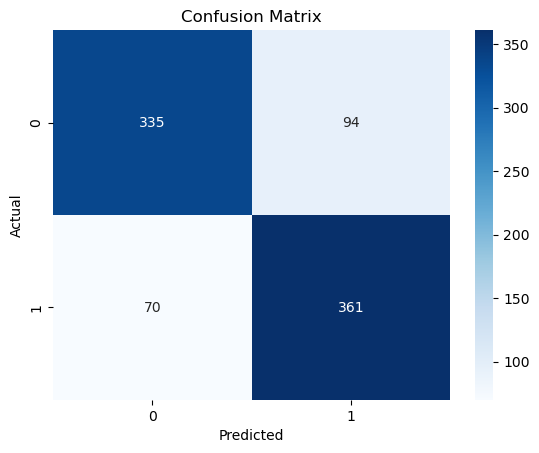

In [11]:
from sklearn.metrics import confusion_matrix

pl = confusion_matrix(y_test, y_pred)

sns.heatmap(pl, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [12]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.78      0.80       429
           1       0.79      0.84      0.81       431

    accuracy                           0.81       860
   macro avg       0.81      0.81      0.81       860
weighted avg       0.81      0.81      0.81       860



## Logistic Regression Model Evaluation Findings

- Accuracy: 0.81  
- Precision: 0.79  
- Recall: 0.84  
- F1 Score: 0.81  

## Classification Report:
#### The model performs similarly on both classes, with precision and recall values around 0.8 for both wildfire and non-wildfire events.
  - True Negatives (no wildfire correctly predicted):** 335
  - False Positives (no wildfire predicted as wildfire): 94
  - False Negatives (wildfire predicted as no wildfire): 70
  - True Positives (wildfire correctly predicted): 361
## Summary: 
The logistic regression model shows a solid score, achieving a balanced performance across in both classes. The model is able to correctly identify most wildfire events, but we can defintely improve the results, especially in reducing false positives and false negatives. More complex models along with cross-validation will likely further improve perfomance.

##### Based on the 4 metrics the best thing to improve would be Recall score, which measures how many actual wildfires we correctly identified, since if we report a false negative this can catsrophopbic to the environment and society.

# Random Forest model

##### Random Forest is a robust ensemble learning algorithm that constructs multiple decision trees and combines their predictions for improved accuracy and stability. It is effective for both classification and regression tasks, handling non-linear relationships and reducing overfitting. 

##### Main objective of these models is to assess the performance on the classification dataset, as we progress and get an idea of how our performance is there will be more tuning the hyperparameters / cross-validation to get the best performance out of all the models.

In [94]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and fit the model
rf = RandomForestClassifier(max_depth=3, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8069767441860465
Precision: 0.7754677754677755
Recall: 0.8654292343387471
F1 Score: 0.8179824561403509

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.75      0.79       429
           1       0.78      0.87      0.82       431

    accuracy                           0.81       860
   macro avg       0.81      0.81      0.81       860
weighted avg       0.81      0.81      0.81       860



### Confusion Matrix

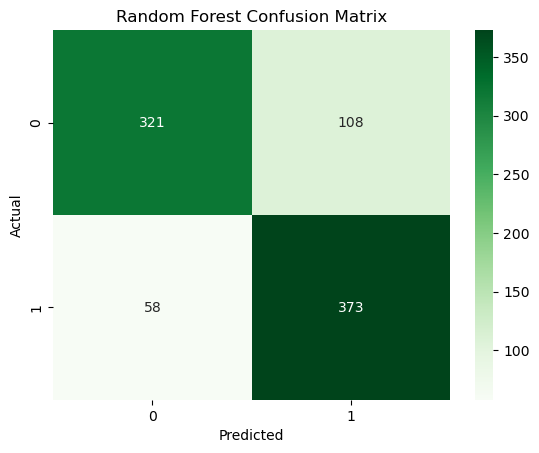

In [95]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

# Summary Random Forest Model

##### Even with a max depth set to 3 we achieve a recal of 87%, so it can predict actual wildfire, this is without hyperparameter tuning. We can accurately capture true wildfires, missing a wildfire can lead to consequences that that we cannot recover from. By limiting the tree depth to 3 we prevent overfitting and see how it generalizes to new unseen data.

In [30]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200],         # Number of trees in the forest
    'max_depth': [3, 5, 10, None],      # Maximum depth of each tree (None means nodes are expanded until all leaves are pure)
    'min_samples_split': [2, 5, 10],    # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],      # Minimum number of samples required to be at a leaf node
    'class_weight': [None, 'balanced']  # Option to automatically adjust weights inversely proportional to class frequencies
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, scoring='recall', cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best recall:", grid_search.best_score_)

Best parameters: {'class_weight': None, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best recall: 0.8853383084577114


##### Using grid seach we found the best hyperparamters in order to the get best recall, we have a max_depth = 5, so we are not overfitting our model, the leaf and split are set to 2, using cross-validation as well, it is tuned for getting the best recall score

In [31]:
best_rf = grid_search.best_estimator_

# Fit is already done on the training set, so you can predict directly
y_pred_best = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best))
print("\nClassification Report:")

print(classification_report(y_test, y_pred_best))

Accuracy: 0.8197674418604651
Precision: 0.7875
Recall: 0.877030162412993
F1 Score: 0.8298572996706916

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.76      0.81       429
           1       0.79      0.88      0.83       431

    accuracy                           0.82       860
   macro avg       0.82      0.82      0.82       860
weighted avg       0.82      0.82      0.82       860



##### After using grid search to find the best hyperparameters, we can see and increase in not only recall, but accuracy, precission, and F1 score, as well. Recall has went up by 0.75% to 0.88%, which is now catching wildfires much more accurately this shows that tuning and finding the best hyperparamters was a necessary step for the Random Forest model. 

##### Now we can move on the next two more complex models such as XGBoost or LightGBM which handles complex patterns such non-linear weather interactions, it captures the most important features, higher accuracy.

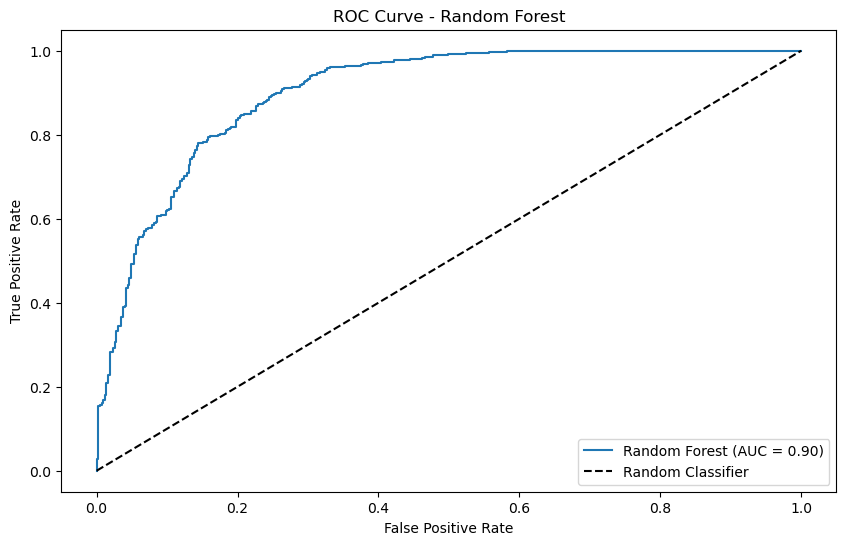

In [128]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (class 1)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

# Compute False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.show()


# XGBoost Model

##### XGBoost is a highly efficient and flexible gradient boosting algorithm, widely used for structured data tasks. It builds an ensemble of decision trees in a sequential manner, optimizing for both speed and performance. In this notebook, we fit a baseline XGBoost model, evaluate its performance, and then perform a hyperparameter search to balance precision and recall using F1 score.

In [ ]:
# %pip install xgboost

##### Use same param grid for both XGBoost and LightGBM model for a fair comparison

In [104]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0],
    'scale_pos_weight': [1, 2]
}

In [105]:
grid_search = GridSearchCV(
    xgb_clf, # type: ignore
    param_grid,
    scoring=['accuracy', 'precision', 'recall', 'f1'],
    refit='f1',  # This will balance precision and recall
    cv=5,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

# Evaluate on test set
best_xgb = grid_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))


Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 50, 'scale_pos_weight': 2, 'subsample': 1.0}
Accuracy: 0.8186046511627907
Precision: 0.7579737335834896
Recall: 0.9373549883990719
F1 Score: 0.8381742738589212

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.70      0.79       429
           1       0.76      0.94      0.84       431

    accuracy                           0.82       860
   macro avg       0.84      0.82      0.82       860
weighted avg       0.84      0.82      0.82       860



##### By default, classifiers use a threshold of 0.5 to decide between classes. However, in imbalanced or high-stakes problems, adjusting this threshold can help balance precision (reducing false alarms) and recall (catching more true wildfires). Here, we increase the threshold to 0.58 to achieve a better tradeoff between precision and recall, based on our project priorities.

In [107]:
y_proba = best_xgb.predict_proba(X_test)[:, 1]

threshold = 0.58
y_pred_thresh = (y_proba >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_thresh))
print("Precision:", precision_score(y_test, y_pred_thresh))
print("Recall:", recall_score(y_test, y_pred_thresh))
print("F1 Score: ", accuracy_score(y_test, y_pred_thresh))

print(classification_report(y_test, y_pred_thresh))

Accuracy: 0.8267441860465117
Precision: 0.7808764940239044
Recall: 0.9095127610208816
F1 Score:  0.8267441860465117
              precision    recall  f1-score   support

           0       0.89      0.74      0.81       429
           1       0.78      0.91      0.84       431

    accuracy                           0.83       860
   macro avg       0.84      0.83      0.83       860
weighted avg       0.84      0.83      0.83       860



**Threshold Tuning Results:**

- `Precision` increased to 78%, meaning fewer false wildfire alarms.
- `Recall` remains high at 91%, so we still catch most true wildfires.
- `F1 score` and overall `accuracy` remain strong and balanced.

##### By tuning the threshold, we can better align the model's predictions for real world balancing the cost of false positives and false negatives.

### Confusion Matrix

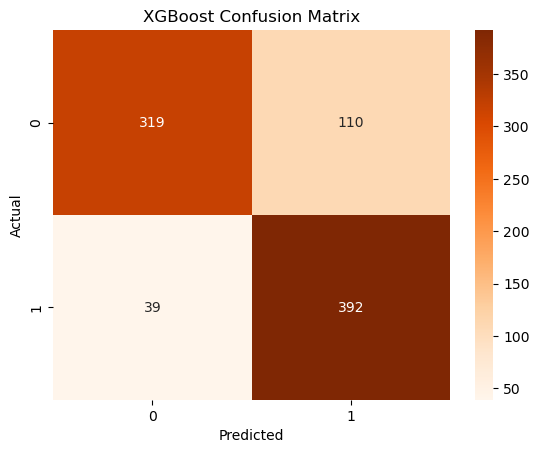

In [108]:
xgb_cm = confusion_matrix(y_test, y_proba >= threshold)
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Oranges')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix')
plt.show()

### Precision-Recall Curve

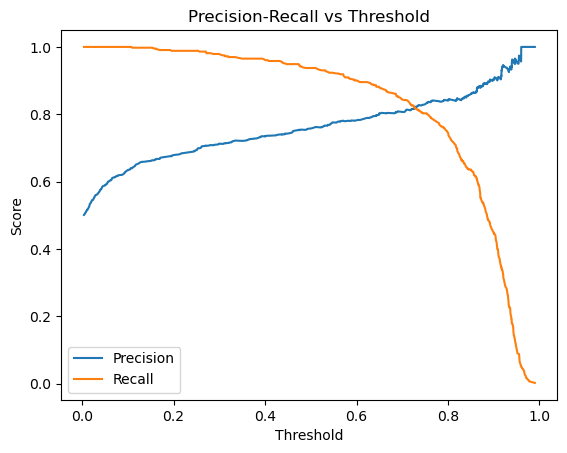

In [66]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.show()

##### This plot shows how precision and recall change as we adjust the decision threshold. It helps us choose a threshold that best matches our project's needs. If we want the best balance of the two the best point would be to choose where they intercept at a threshold of 0.7, this would achieve a score of 0.8 for both precision and recall, but for the sake of this project we want to priortize actual prediction of wildfires, hence focus on recall.

## ROC Curve

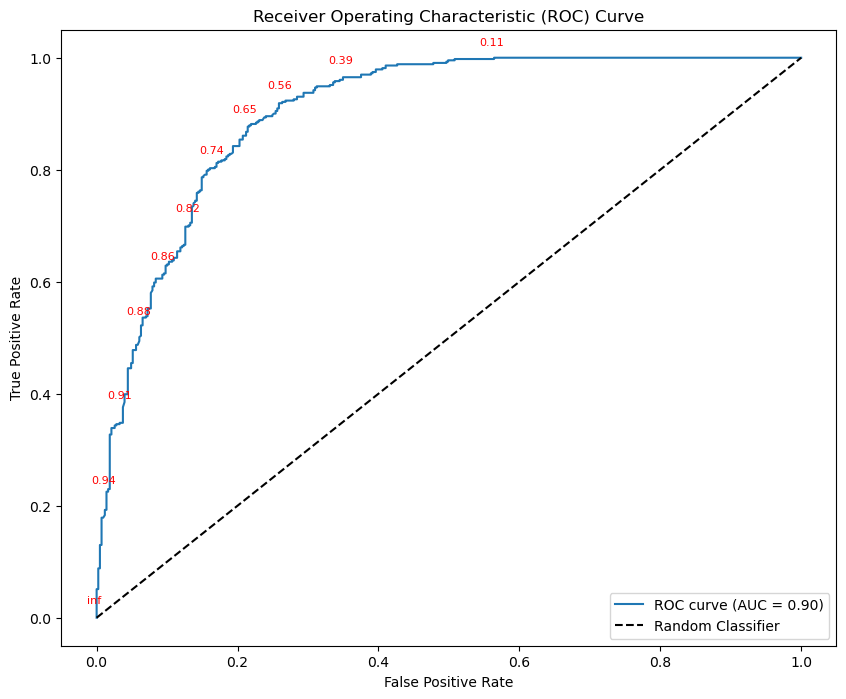

In [93]:
from sklearn.metrics import roc_curve, auc

y_proba = best_xgb.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

# Annotate a few threshold values on the curve
for i in range(0, len(thresholds), max(1, len(thresholds)//10)):
    plt.annotate(f'{thresholds[i]:.2f}', (fpr[i], tpr[i]), textcoords="offset points", xytext=(-2,10), ha='center', fontsize=8, color='red')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

##### This ROC curve is score indicates another way to assess the models True positive rate (TPR) vs False positive rates (FPR), we can see that with a threshold of 0.58 the model will incorrectly indentify a FPR with 0.25, that means, it means the model is strong is strong with identifying actual wildfires, but performs poorely on non wildfire as wildfire, this is a tradeoff we saw earlier.

# LightGBM Model

LightGBM is another powerful gradient boosting algorithm, often faster and more efficient than XGBoost. Here, we fit a baseline LightGBM model, evaluate its performance, and then perform a quick hyperparameter search to balance precision and recall using F1 score.

In [121]:
import lightgbm as lgb

lgb_clf = lgb.LGBMClassifier(random_state=42)
lgb_clf.fit(X_train, y_train)
y_pred_lgb = lgb_clf.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred_lgb))
print("Precision:", precision_score(y_test, y_pred_lgb))
print("Recall:", recall_score(y_test, y_pred_lgb))
print("F1 Score:", f1_score(y_test, y_pred_lgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgb))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1003, number of negative: 1001
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000134 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1100
[LightGBM] [Info] Number of data points in the train set: 2004, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500499 -> initscore=0.001996
[LightGBM] [Info] Start training from score 0.001996

Accuracy: 0.8313953488372093
Precision: 0.8177777777777778
Recall: 0.8538283062645011
F1 Score: 0.8354143019296254

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       429
           1       0.82      0.85      0.84       431

    accuracy                           0.83       860
   macro avg       0.83      0.83      0.83       860
weighted avg       

### Confusion Matrix

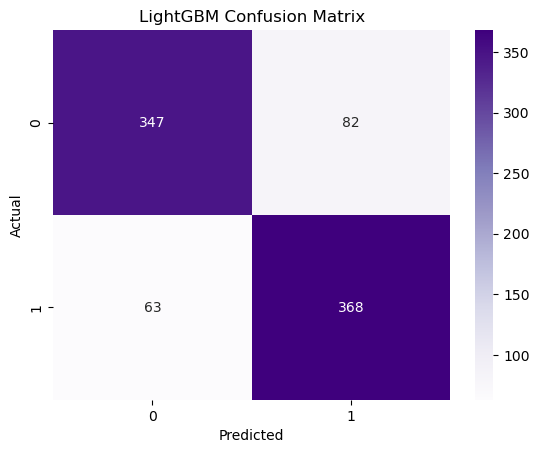

In [110]:
# Confusion Matrix
cm_lgb = confusion_matrix(y_test, y_pred_lgb)
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Purples')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('LightGBM Confusion Matrix')
plt.show()

In [118]:
grid_search_lgb = GridSearchCV(
    lgb.LGBMClassifier(random_state=42),
    param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)
grid_search_lgb.fit(X_train, y_train)

print("Best LightGBM Parameters:", grid_search_lgb.best_params_)

best_lgb = grid_search_lgb.best_estimator_
y_pred_best_lgb = best_lgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best_lgb))
print("Precision:", precision_score(y_test, y_pred_best_lgb))
print("Recall:", recall_score(y_test, y_pred_best_lgb))
print("F1 Score:", f1_score(y_test, y_pred_best_lgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_lgb))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1003, number of negative: 1001
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000175 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1100
[LightGBM] [Info] Number of data points in the train set: 2004, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500499 -> initscore=0.001996
[LightGBM] [Info] Start training from score 0.001996
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

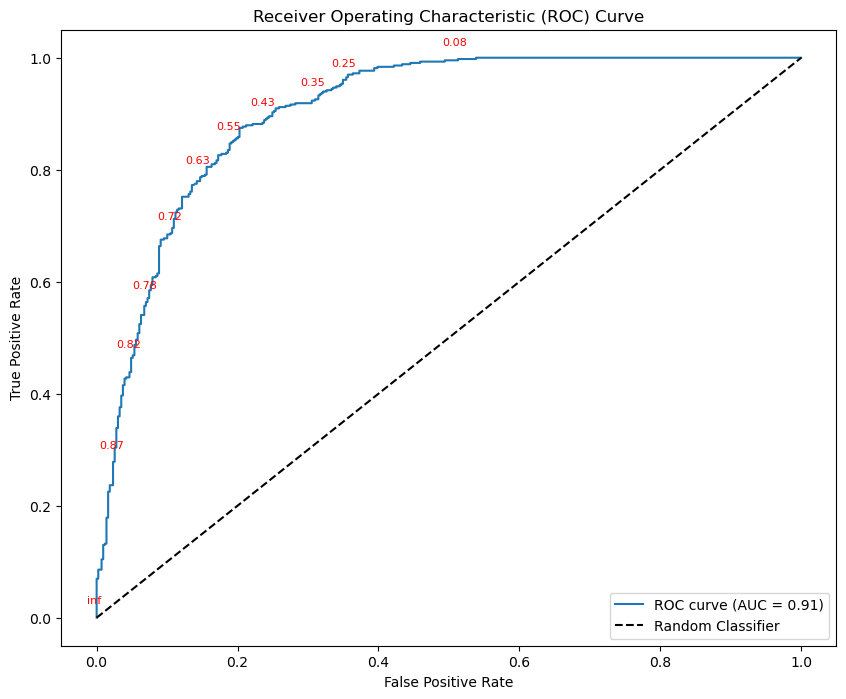

In [125]:
y_proba = best_lgb.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, best_lgb.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

# Annotate a few threshold values on the curve
for i in range(0, len(thresholds), max(1, len(thresholds)//10)):
    plt.annotate(f'{thresholds[i]:.2f}', (fpr[i], tpr[i]), textcoords="offset points", xytext=(-2,10), ha='center', fontsize=8, color='red')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

##### From cross-validation the average recall was at 0.87 but for the ROC curve on this particular test set it got a score of XGBoost model of 0.91, but we will choose the XGBoost model since it performed 0.91 on recall on overall more training / test split.

# Report

In the modeling phase, we evaluated several machine learning algorithms to predict wildfire occurrence in California, using both baseline and tuned versions of each model. The goal was to maximize recall, finding as many true wildfire events as possible while ensuring a balanced precision and overall accuracy.

Logistic Regression served as a startup, achieving solid and balanced performance with an accuracy of 0.81, precision of 0.79, and recall of 0.84. The model performed similarly on both wildfire and non-wildfire events, but left room for improvement, especially in reducing false negatives.

Random Forest improved recall to 0.87 even before hyperparameter tuning, demonstrating its strength in capturing complex, non-linear relationships. After grid search optimization, the model further increased recall to 0.88 and overall prediction power for the other metrics, showing that tuning in the next more complex models would need to be added to ensure the best results.

XGBoost, a powerful gradient boosting algorithm, delivered the highest recall (0.94) and strong overall metrics after threshold tuning. By adjusting the classification threshold, we achieved a better balance between precision (0.78) and recall (0.91), making the model highly effective at catching true wildfires while minimizing false alarms. The ROC AUC for XGBoost reached 0.91, showcasing a good tradeoff between TPR and FPR.

LightGBM offered similar performance to XGBoost, with a recall of 0.87 and ROC AUC of 0.91 on the test set. While cross-validation recall averaged 0.87, the model performed slightly better on the test split, reflecting the variability inherent in different data partitions. LightGBM’s speed and efficiency make it a strong alternative for large datasets.

Overall, all advanced models outperformed logistic regression, with XGBoost being the winner for recall. This is the model I would ultimately deliver for real-world testing. LightGBM provided the best trade-off between recall and precision. The focus on recall is critical with the high cost of missing wildfire events, while threshold tuning and hyperparameter optimization allowed for a robust model with real-world performance. These results highlight how weather and seasonal patterns are key predictors, and demonstrate the value of ensemble methods for wildfire prediction in California.